In [2453]:
import numpy as np
import pandas as pd
from numpy import genfromtxt
from brainflow.board_shim import BoardShim, BoardIds
from brainflow.data_filter import DataFilter, FilterTypes
import matplotlib.pyplot as plt
from scipy.signal import welch

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from scipy.signal import butter, filtfilt, iirnotch
from scipy.stats import zscore
import seaborn as sns



In [2454]:
SAMPLING_RATE = 256
N_CHANNELS = 8

In [2455]:
def load_openbci_txt(file):

    df = pd.read_csv(
    file,
    skiprows=4
    )

    eeg_columns = [
        " EXG Channel 0",
        " EXG Channel 1",
        " EXG Channel 2",
        " EXG Channel 3",
        " EXG Channel 4",
        " EXG Channel 5",
        " EXG Channel 6",
        " EXG Channel 7"
    ]

    eeg = df[eeg_columns].values

    return eeg

In [2456]:
def trim_data(data, trim_length=20, fs=256):
    trim_samples = trim_length * fs
    return data[trim_samples:-trim_samples]

In [2457]:
def load_eeg(file):

    if file.endswith(".txt"):
        return load_openbci_txt(file)

    else:
        df = pd.read_csv(file, sep='\t', comment='%',header=None)
        return df.iloc[1:,1:9].values

In [2458]:
# baseline_files = [
#     "/Users/chloejin/Documents/OpenBCI_GUI/Recordings/Basline_1/BrainFlow-RAW_2026-03-07_16-29-14_0.csv",
#     "/Users/chloejin/Documents/OpenBCI_GUI/Recordings/Baseline_2/BrainFlow-RAW_2026-03-07_21-16-31_0.csv",
#     "/Users/chloejin/Documents/OpenBCI_GUI/Recordings/Baseline_3/OpenBCI-RAW-2026-03-07_21-19-26.txt"
# ]

thinking_files = [
    "/Users/chloejin/Documents/OpenBCI_GUI/Recordings/OpenBCISession_2026-03-08_04-17-27/OpenBCI-RAW-2026-03-08_04-17-59.txt",
    "/Users/chloejin/Documents/OpenBCI_GUI/Recordings/OpenBCISession_2026-03-08_04-11-42/BrainFlow-RAW_2026-03-08_04-11-42_0.csv",
    "/Users/chloejin/Documents/OpenBCI_GUI/Recordings/OpenBCISession_2026-03-08_04-14-53/BrainFlow-RAW_2026-03-08_04-14-53_0.csv"
]

movement_files = [
    "/Users/chloejin/Documents/OpenBCI_GUI/Recordings/OpenBCISession_2026-03-08_03-59-23/BrainFlow-RAW_2026-03-08_03-59-23_0.csv",
    "/Users/chloejin/Documents/OpenBCI_GUI/Recordings/OpenBCISession_2026-03-08_04-01-41/BrainFlow-RAW_2026-03-08_04-01-41_0.csv",
    "/Users/chloejin/Documents/OpenBCI_GUI/Recordings/OpenBCISession_2026-03-08_04-03-56/BrainFlow-RAW_2026-03-08_04-03-56_0.csv"
]

In [2459]:
# baseline_data = [trim_data(load_eeg(f)) for f in baseline_files]
thinking_data = [trim_data(load_eeg(f)) for f in thinking_files]
movement_data = [trim_data(load_eeg(f)) for f in movement_files]

Filtering


In [2460]:
def bandpass_filter(data, low=1, high=40, fs=256, order=4):

    nyq = fs/2
    low = low/nyq
    high = high/nyq

    b,a = butter(order,[low,high],btype='band')

    return filtfilt(b,a,data,axis=0)


def notch_filter(data, freq=60, fs=256, Q=30):

    b,a = iirnotch(freq, Q, fs)

    return filtfilt(b,a,data,axis=0)

In [2461]:
def preprocess_trial(data):

    data = bandpass_filter(data)
    data = notch_filter(data)

    return data


baseline_data = [preprocess_trial(d) for d in baseline_data]
thinking_data = [preprocess_trial(d) for d in thinking_data]
movement_data = [preprocess_trial(d) for d in movement_data]

Epoching

In [2462]:
def epoch_data(data, epoch_length=2, fs=256):

    samples = epoch_length * fs

    epochs = []

    for start in range(5*fs, len(data)-samples, samples - 5*fs):

        epoch = data[start:start+samples]

        epochs.append(epoch)

    return np.array(epochs)

In [2463]:
# baseline_epochs = [epoch_data(d) for d in baseline_data]
thinking_epochs = [epoch_data(d) for d in thinking_data]
movement_epochs = [epoch_data(d) for d in movement_data]

PLOT1: RAW

In [2464]:
def plot_raw_eeg(data, fs=256):

    n_samples, n_channels = data.shape
    t = np.arange(n_samples) / fs

    plt.figure(figsize=(12,6))

    for ch in range(n_channels):
        plt.plot(t, data[:,ch] + ch*50)

    plt.xlabel("Time (s)")
    plt.ylabel("Channels")
    plt.title("Raw EEG Signal")
    plt.legend([f"Ch {i}" for i in range(n_channels)])
    plt.show()

In [2465]:
baseline_data[0].shape

(8290, 8)

In [2466]:
selection = [int(10*256), int(50*256)]
# baseline_data_all = np.array([baseline_data[i][selection[0]:selection[1], 2:4] for i in range(len(baseline_data))])
# baseline_data_mean = np.mean(baseline_data_all, axis=0)

thinking_data_all = np.array([thinking_data[i][selection[0]:selection[1], :] for i in range(len(thinking_data))])
thinking_data_mean = np.mean(thinking_data_all, axis=0)

movement_data_all = np.array([movement_data[i][selection[0]:selection[1], :] for i in range(len(movement_data))])
movement_data_mean = np.mean(movement_data_all, axis=0)

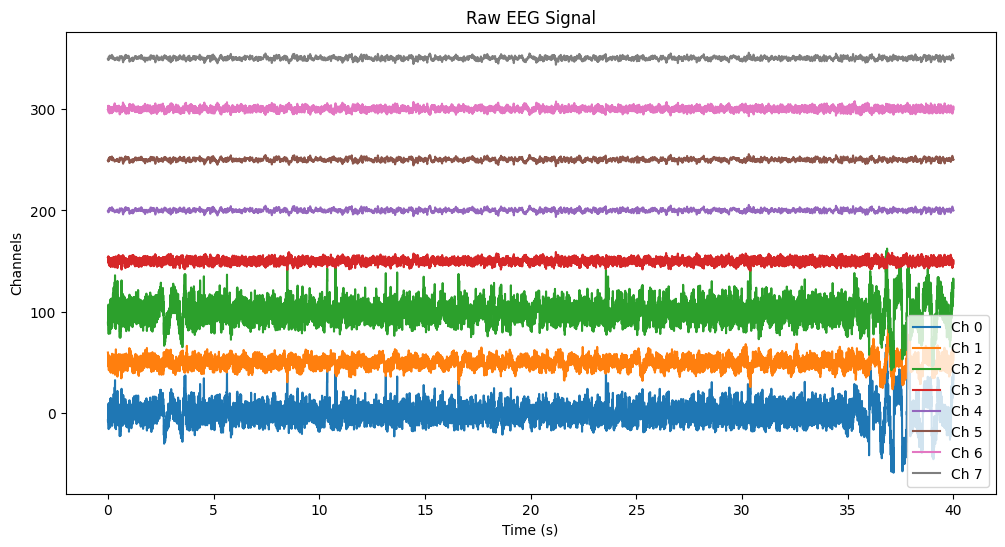

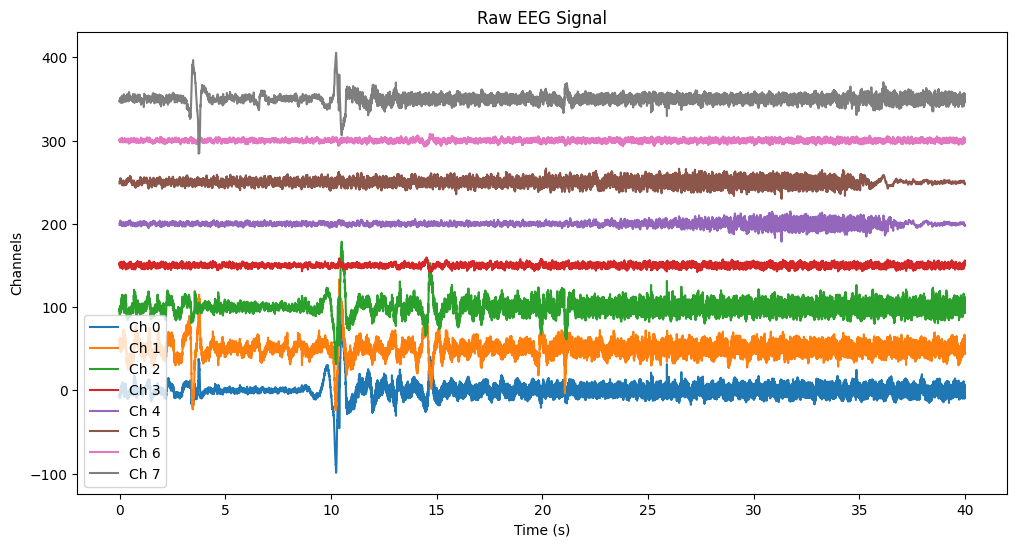

In [2467]:
# plot_raw_eeg(baseline_data_mean)
plot_raw_eeg(thinking_data_mean)
plot_raw_eeg(movement_data_mean)

In [2468]:
from scipy.signal import welch

def alpha_power(signal, fs=256):

    f, psd = welch(signal, fs=fs, nperseg=fs*2)

    alpha_idx = (f >= 8) & (f <= 12)

    return np.trapz(psd[alpha_idx], f[alpha_idx])

In [2469]:
def alpha_power_timeseries(data, fs=256, window=64, step=32):

    n_samples, n_channels = data.shape
    powers = []

    for start in range(0, n_samples-window + 1, step):

        segment = data[start:start+window, :]

        # average alpha power across channels
        ch_power = []

        for ch in range(n_channels):
            ch_power.append(alpha_power(segment[:,ch], fs))

        powers.append(np.mean(ch_power))

    return np.array(powers)

In [2470]:
from scipy.signal import welch

def beta_power(signal, fs=256):

    f, psd = welch(signal, fs=fs, nperseg=fs*2)

    beta_idx = (f >= 13) & (f <= 30)

    return np.trapz(psd[beta_idx], f[beta_idx])

In [2471]:
def beta_power_timeseries(data, fs=256, window=64, step=32):

    n_samples, n_channels = data.shape
    powers = []

    for start in range(0, n_samples-window + 1, step):

        segment = data[start:start+window, :]

        # average beta power across channels
        ch_power = []

        for ch in range(n_channels):
            ch_power.append(beta_power(segment[:,ch], fs))

        powers.append(np.mean(ch_power))

    return np.array(powers)

In [2472]:
def plot_psd(data, fs=256):

    signal = np.mean(data, axis=1)

    f, psd = welch(signal, fs=fs)

    plt.plot(f, psd)

    plt.xlim(0,40)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power")
    plt.title("Power Spectral Density")

    plt.show()

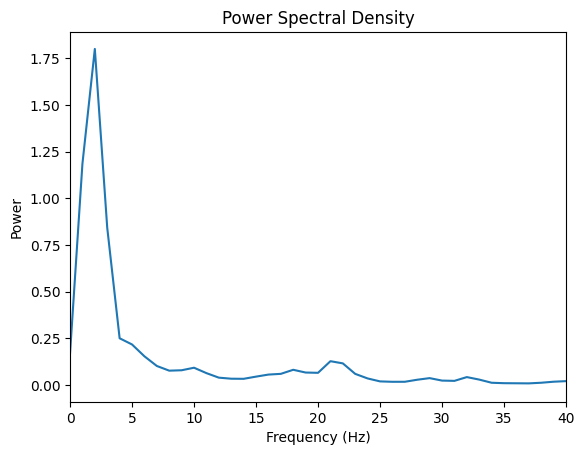

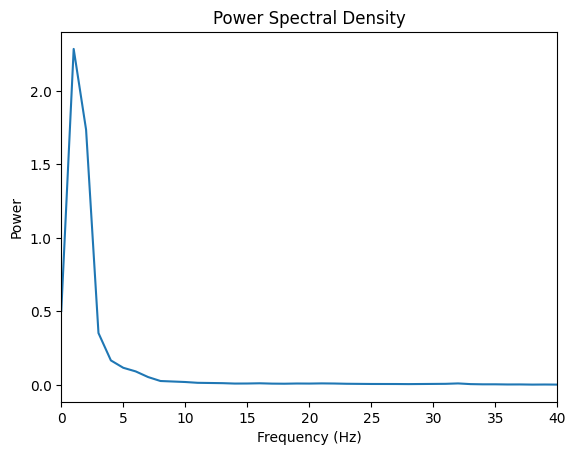

In [2473]:
# plot_psd(baseline_data_mean)
plot_psd(thinking_data_mean)
plot_psd(movement_data_mean)

In [2474]:
def normalize(data):

    return zscore(data, axis=0)

In [2475]:
baseline_data = [normalize(d) for d in baseline_data]
thinking_data = [normalize(d) for d in thinking_data]
movement_data = [normalize(d) for d in movement_data]

Windowing

In [2476]:
def sliding_window(epoch, window_size=1, step=0.5, fs=256):

    win = int(window_size*fs)
    step = int(step*fs)

    windows = []

    for i in range(0, len(epoch)-win, step):

        windows.append(epoch[i:i+win])

    return np.array(windows)

LCA artifact removal

In [2477]:
import mne

def apply_ica(data):

    info = mne.create_info(
        ch_names=[f"ch{i}" for i in range(8)],
        sfreq=256,
        ch_types="eeg"
    )

    raw = mne.io.RawArray(data.T, info)

    ica = mne.preprocessing.ICA(
        n_components=8,
        random_state=0,
        max_iter=800
    )

    ica.fit(raw)

    raw_corrected = ica.apply(raw.copy())

    return raw_corrected.get_data().T

In [2478]:
baseline_data = [apply_ica(d) for d in baseline_data]
thinking_data = [apply_ica(d) for d in thinking_data]
movement_data = [apply_ica(d) for d in movement_data]

Creating RawArray with float64 data, n_channels=8, n_times=8290
    Range : 0 ... 8289 =      0.000 ...    32.379 secs
Ready.
Fitting ICA to data using 8 channels (please be patient, this may take a while)
Selecting by number: 8 components
Fitting ICA took 0.0s.
Applying ICA to Raw instance
    Transforming to ICA space (8 components)
    Zeroing out 0 ICA components
    Projecting back using 8 PCA components
Creating RawArray with float64 data, n_channels=8, n_times=8385
    Range : 0 ... 8384 =      0.000 ...    32.750 secs
Ready.
Fitting ICA to data using 8 channels (please be patient, this may take a while)
Selecting by number: 8 components


/var/folders/zf/vpkw2cc51fn9fgp52wfd5l000000gn/T/ipykernel_11672/576385930.py:19: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(raw)
/var/folders/zf/vpkw2cc51fn9fgp52wfd5l000000gn/T/ipykernel_11672/576385930.py:19: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(raw)


Fitting ICA took 0.5s.
Applying ICA to Raw instance
    Transforming to ICA space (8 components)
    Zeroing out 0 ICA components
    Projecting back using 8 PCA components
Creating RawArray with float64 data, n_channels=8, n_times=8380
    Range : 0 ... 8379 =      0.000 ...    32.730 secs
Ready.
Fitting ICA to data using 8 channels (please be patient, this may take a while)
Selecting by number: 8 components


/opt/anaconda3/envs/NHT5/lib/python3.10/site-packages/sklearn/decomposition/_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
/var/folders/zf/vpkw2cc51fn9fgp52wfd5l000000gn/T/ipykernel_11672/576385930.py:19: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(raw)


Fitting ICA took 0.5s.
Applying ICA to Raw instance
    Transforming to ICA space (8 components)
    Zeroing out 0 ICA components
    Projecting back using 8 PCA components
Creating RawArray with float64 data, n_channels=8, n_times=15955
    Range : 0 ... 15954 =      0.000 ...    62.320 secs
Ready.
Fitting ICA to data using 8 channels (please be patient, this may take a while)
Selecting by number: 8 components
Fitting ICA took 0.0s.
Applying ICA to Raw instance
    Transforming to ICA space (8 components)
    Zeroing out 0 ICA components
    Projecting back using 8 PCA components
Creating RawArray with float64 data, n_channels=8, n_times=15557
    Range : 0 ... 15556 =      0.000 ...    60.766 secs
Ready.
Fitting ICA to data using 8 channels (please be patient, this may take a while)
Selecting by number: 8 components
Fitting ICA took 0.0s.
Applying ICA to Raw instance
    Transforming to ICA space (8 components)
    Zeroing out 0 ICA components
    Projecting back using 8 PCA componen

/opt/anaconda3/envs/NHT5/lib/python3.10/site-packages/sklearn/decomposition/_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
/var/folders/zf/vpkw2cc51fn9fgp52wfd5l000000gn/T/ipykernel_11672/576385930.py:19: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(raw)
/var/folders/zf/vpkw2cc51fn9fgp52wfd5l000000gn/T/ipykernel_11672/576385930.py:19: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(raw)
/var/folders/zf/vpkw2cc51fn9fgp52wfd5l000000gn/T/ipykernel_11672/576385930.py:19: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitt

    Zeroing out 0 ICA components
    Projecting back using 8 PCA components
Creating RawArray with float64 data, n_channels=8, n_times=13579
    Range : 0 ... 13578 =      0.000 ...    53.039 secs
Ready.
Fitting ICA to data using 8 channels (please be patient, this may take a while)
Selecting by number: 8 components
Fitting ICA took 0.0s.
Applying ICA to Raw instance
    Transforming to ICA space (8 components)
    Zeroing out 0 ICA components
    Projecting back using 8 PCA components


/var/folders/zf/vpkw2cc51fn9fgp52wfd5l000000gn/T/ipykernel_11672/576385930.py:19: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(raw)


Feature extraction

In [2479]:
def extract_features(epochs):

    features = []

    for epoch in epochs:

        alpha = alpha_power(epoch,(8,12))
        beta = beta_power(epoch,(13,30))

        feature = np.concatenate([alpha,beta])

        features.append(feature)

    return np.array(features)

In [2480]:
alpha_matrix = []

for d in movement_data_all:

    row = []

    for ch in range(8):

        row.append(alpha_power(d[:,ch],256))

    alpha_matrix.append(row)

alpha_matrix = np.array(alpha_matrix)

/var/folders/zf/vpkw2cc51fn9fgp52wfd5l000000gn/T/ipykernel_11672/3767349106.py:9: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(psd[alpha_idx], f[alpha_idx])


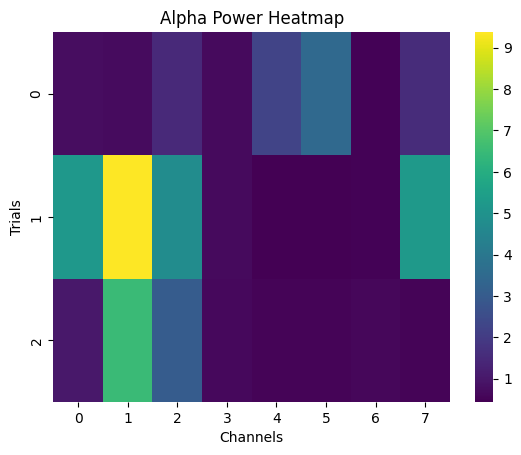

In [2481]:
sns.heatmap(alpha_matrix, cmap="viridis")

plt.xlabel("Channels")
plt.ylabel("Trials")
plt.title("Alpha Power Heatmap")

plt.show()